In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = "Arial"

In [2]:
mpl.rcParams.update({
    "figure.figsize": (6, 6),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.sans-serif": ["DejaVu Sans"],  # 稳定
    # 不设置 pdf.fonttype = 42
})

In [3]:
adata = sc.read_h5ad(r"E:\KCL\scRNAseq\scRNAseq\mouse\GSM6160615_adata\phd thesis\hfd_mouse_islet_scRNAseq_raw_counts.h5ad")

In [4]:
beta_subtypes = ["β-s1", "β-s2", "β-s3", "β-s4"]

adata.obs["leiden_new"] = adata.obs["leiden"].apply(lambda x: "β" if x in beta_subtypes else x)

In [5]:
list(set(adata.obs["leiden_new"]))

['γ', 'δ', 'Endothelial', 'MSC', 'Macrophage', 'Ductal', 'β', 'α']

In [6]:
adata.obs["leiden_new"] = adata.obs["leiden_new"].astype("category")

new_order = ['α', 'β', 'δ', 'γ', 'Ductal', 'MSC', 'Endothelial', 'Macrophage'] 
adata.obs["leiden_new"] = adata.obs["leiden_new"].cat.reorder_categories(new_order, ordered=True)

In [7]:
adata.obs

,pseudo_group,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,leiden_new,batch
AAACCTGAGGCCATAG-1-HFD,5,1463,1463,7476.0,187.0,2.501338,β-s3,β,HFD
AAACCTGCAGACACTT-1-HFD,4,2523,2523,17820.0,391.0,2.194164,β-s2,β,HFD
AAACCTGCAGCCTATA-1-HFD,5,1767,1767,7064.0,441.0,6.242922,β-s2,β,HFD
AAACCTGGTCTCTCTG-1-HFD,4,1805,1805,5813.0,293.0,5.040427,β-s2,β,HFD
AAACGGGAGACTACAA-1-HFD,5,1670,1670,4132.0,66.0,1.597289,β-s1,β,HFD
...,...,...,...,...,...,...,...,...,...
TTTGTCATCAAAGTAG-1-CD,3,2075,2075,9095.0,334.0,3.672348,γ,γ,CD
TTTGTCATCATCGCTC-1-CD,3,2081,2081,9581.0,686.0,7.160004,β-s1,β,CD
TTTGTCATCGTGGTCG-1-CD,3,1277,1277,4768.0,213.0,4.467282,β-s3,β,CD
TTTGTCATCTGCGGCA-1-CD,2,2101,2101,11558.0,201.0,1.739055,γ,γ,CD


saving figure to file figures\umapfig2a_umap.png


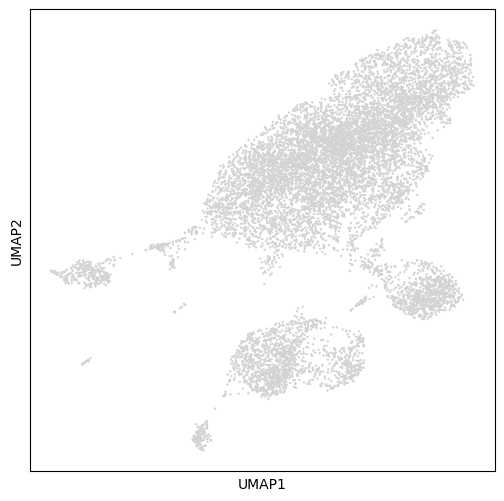

In [8]:
sc.pl.umap(adata, save='fig2a_umap.png')

saving figure to file figures\umapfig2b_umap_batch.png


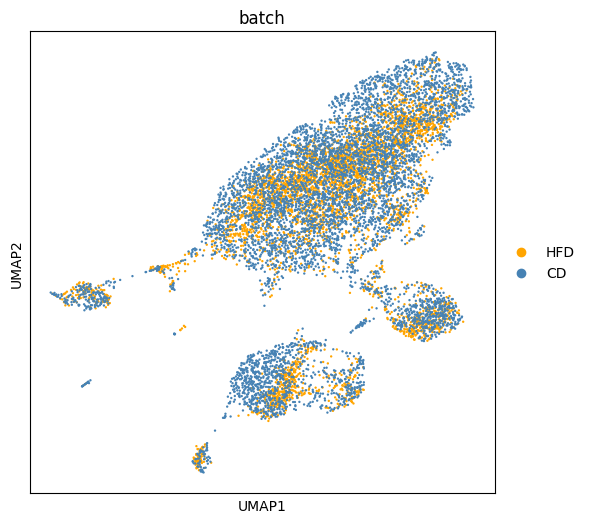

In [9]:
sc.pl.umap(adata, color='batch', save='fig2b_umap_batch.png')

saving figure to file figures\umapfig2c_umap_leiden.png


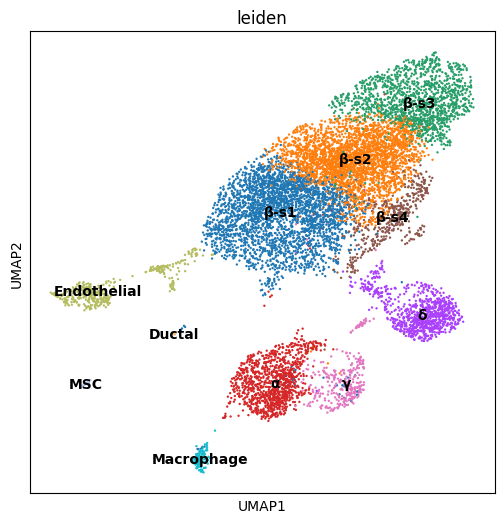

In [10]:
sc.pl.umap(adata, color='leiden', legend_loc= "on data", save='fig2c_umap_leiden.png')

saving figure to file figures\umapfig2d_umap_leiden_new.png


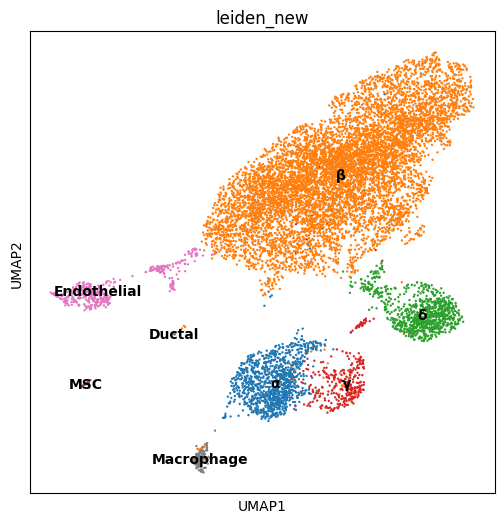

In [11]:
sc.pl.umap(adata, color='leiden_new', legend_loc= "on data", save='fig2d_umap_leiden_new.png')

In [12]:
adata.obs

,pseudo_group,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,leiden_new,batch
AAACCTGAGGCCATAG-1-HFD,5,1463,1463,7476.0,187.0,2.501338,β-s3,β,HFD
AAACCTGCAGACACTT-1-HFD,4,2523,2523,17820.0,391.0,2.194164,β-s2,β,HFD
AAACCTGCAGCCTATA-1-HFD,5,1767,1767,7064.0,441.0,6.242922,β-s2,β,HFD
AAACCTGGTCTCTCTG-1-HFD,4,1805,1805,5813.0,293.0,5.040427,β-s2,β,HFD
AAACGGGAGACTACAA-1-HFD,5,1670,1670,4132.0,66.0,1.597289,β-s1,β,HFD
...,...,...,...,...,...,...,...,...,...
TTTGTCATCAAAGTAG-1-CD,3,2075,2075,9095.0,334.0,3.672348,γ,γ,CD
TTTGTCATCATCGCTC-1-CD,3,2081,2081,9581.0,686.0,7.160004,β-s1,β,CD
TTTGTCATCGTGGTCG-1-CD,3,1277,1277,4768.0,213.0,4.467282,β-s3,β,CD
TTTGTCATCTGCGGCA-1-CD,2,2101,2101,11558.0,201.0,1.739055,γ,γ,CD


In [14]:
adata_beta = adata[adata.obs['leiden'].isin(["β-s1","β-s2","β-s3","β-s4"])]

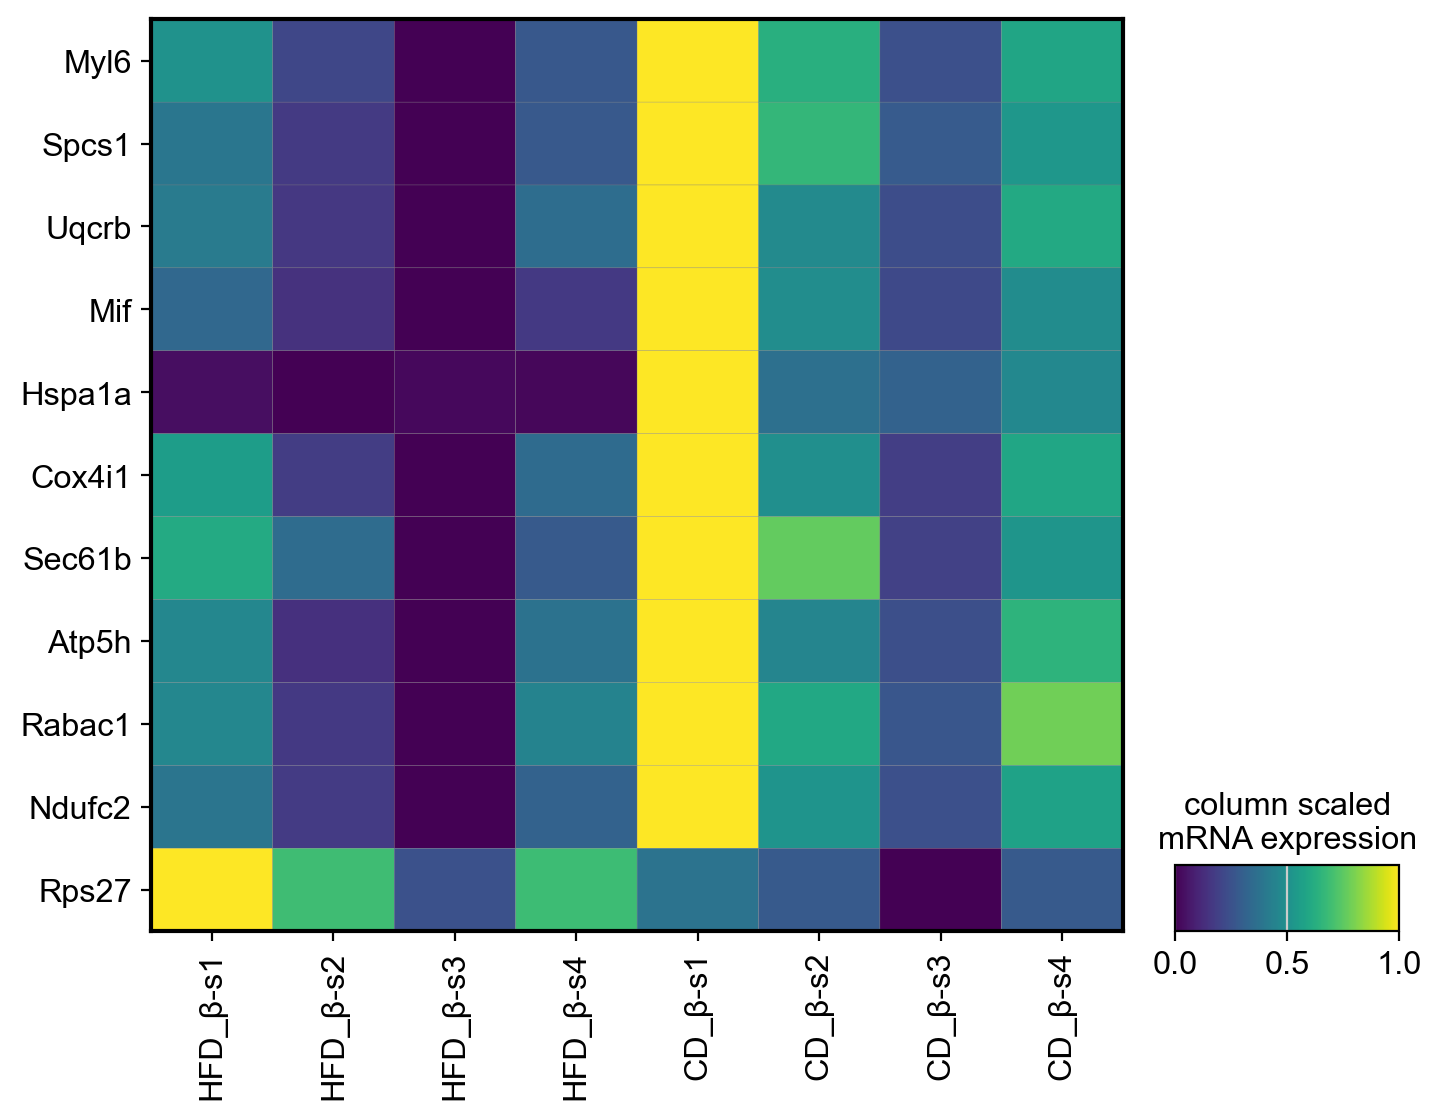

In [18]:
markers = [
    "Myl6",
    "Spcs1",
    "Uqcrb",
    "Mif",
    "Hspa1a",
    "Cox4i1",
    "Sec61b",
    "Atp5h",
    "Rabac1",
    "Ndufc2",
    "Rps27"
]

sc.pl.matrixplot(adata_beta, markers, ['batch','leiden'], dendrogram=False, cmap='viridis',figsize=(8, 6),
                standard_scale='var', colorbar_title='column scaled\nmRNA expression', swap_axes=True)

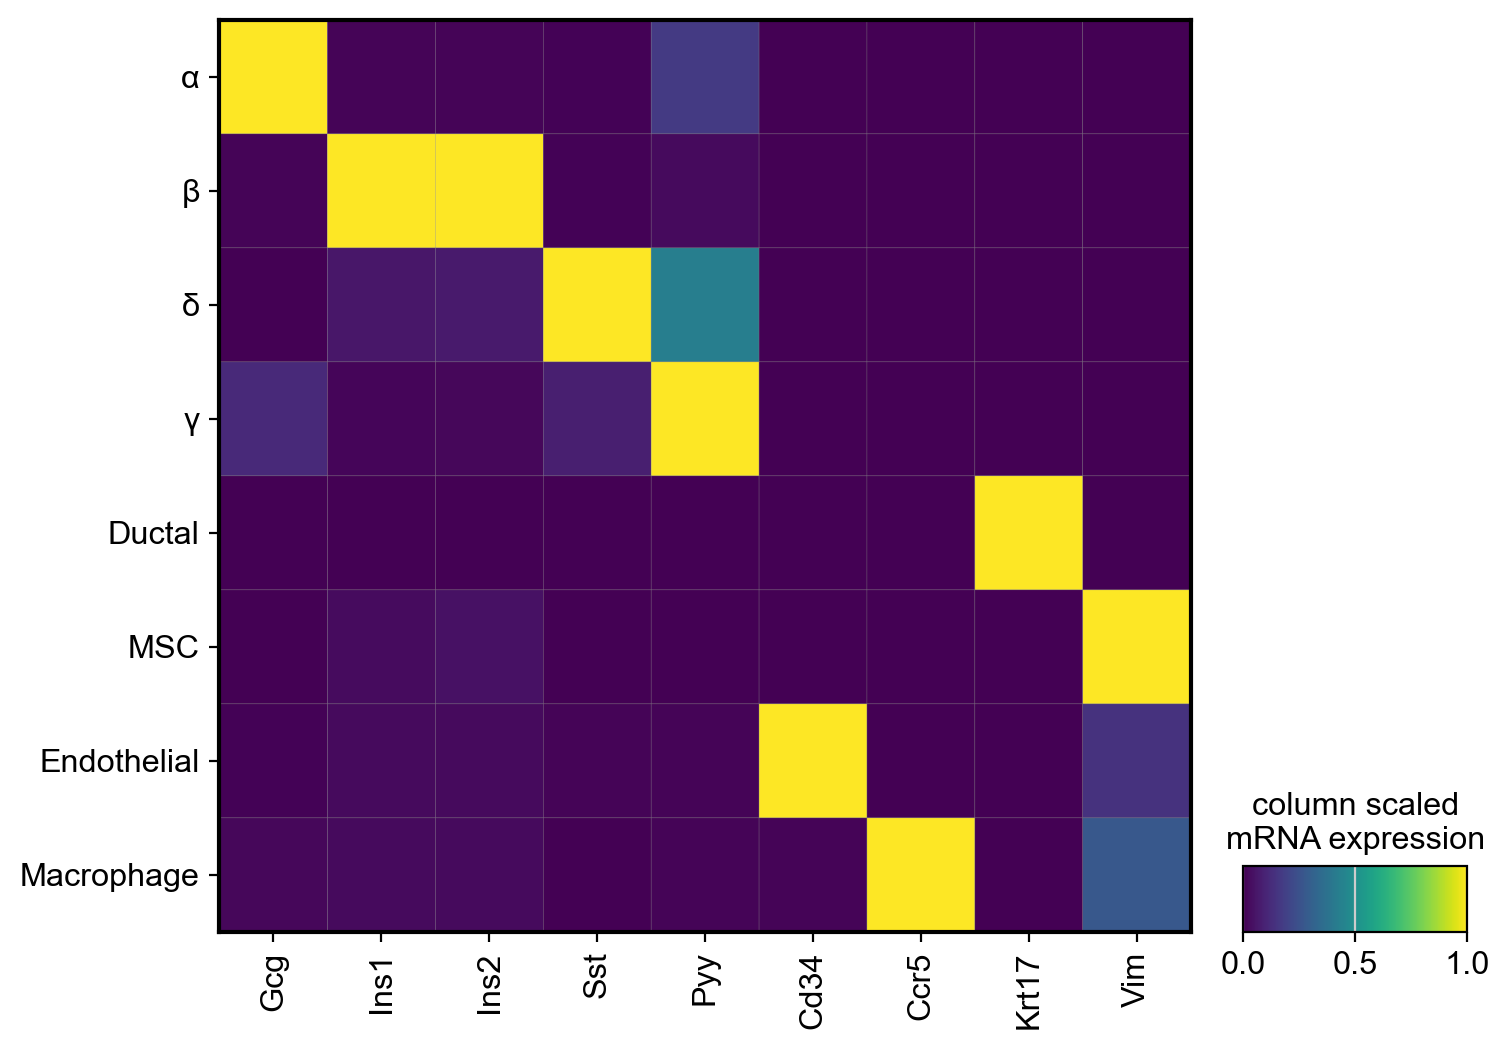

In [27]:
markers = [
    "Gcg",
    "Ins1",
    "Ins2",
    "Sst",
    "Pyy",
    "Cd34",
    "Ccr5",
    "Krt17",
    "Vim"
]

sc.pl.matrixplot(adata, markers, 'leiden_new', dendrogram=False, cmap='viridis',figsize=(8, 6),
                standard_scale='var', colorbar_title='column scaled\nmRNA expression', swap_axes=False)

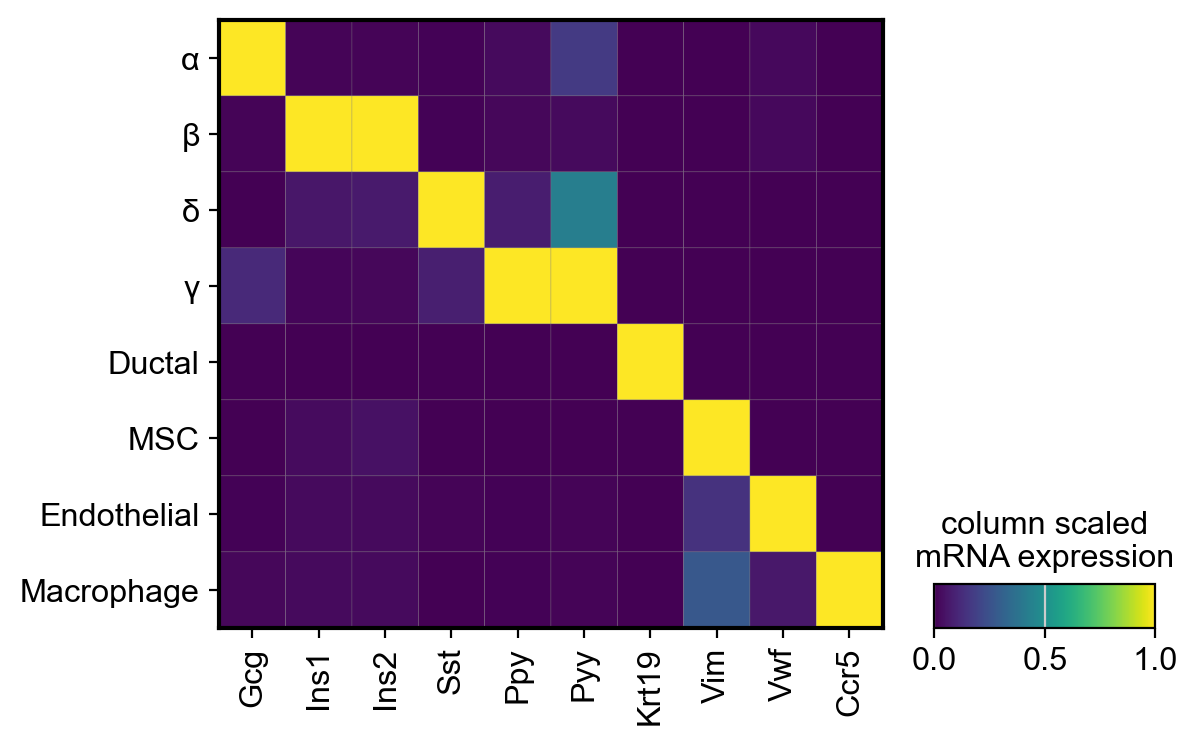

In [13]:
markers = [
    "Gcg",
    "Ins1",
    "Ins2",
    "Sst",
    "Ppy",
    "Pyy",
    "Krt19",
    "Vim",
    "Vwf",
    "Ccr5",
]

sc.pl.matrixplot(adata, markers, 'leiden_new', dendrogram=False, cmap='viridis',figsize=(6, 4),
                standard_scale='var', colorbar_title='column scaled\nmRNA expression', swap_axes=False, save='fig2e_heatmap.png')

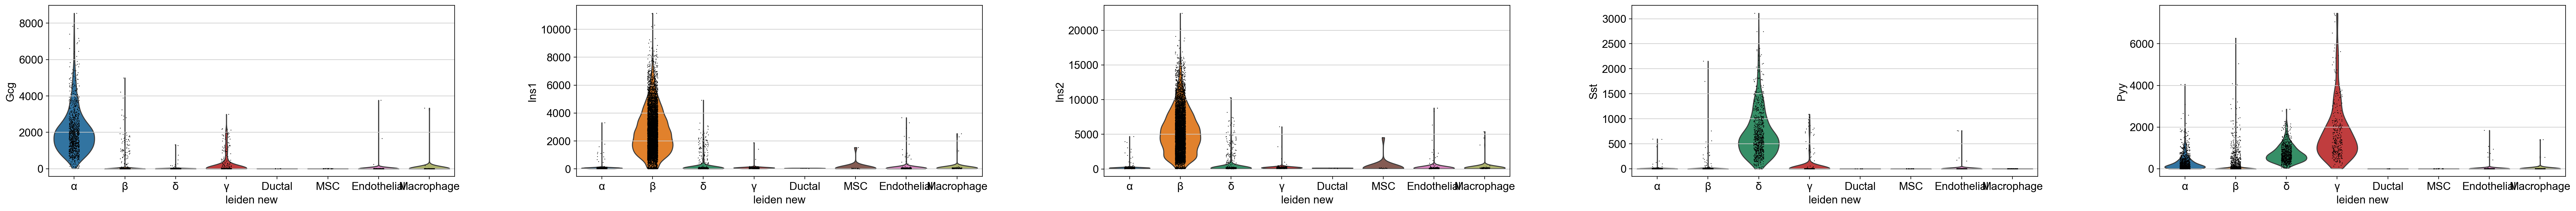

In [58]:
hormones = [
    "Gcg",
    "Ins1",
    "Ins2",
    "Sst",
    "Pyy"
]
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(8, 4))
sc.pl.violin(adata, hormones, groupby='leiden_new')

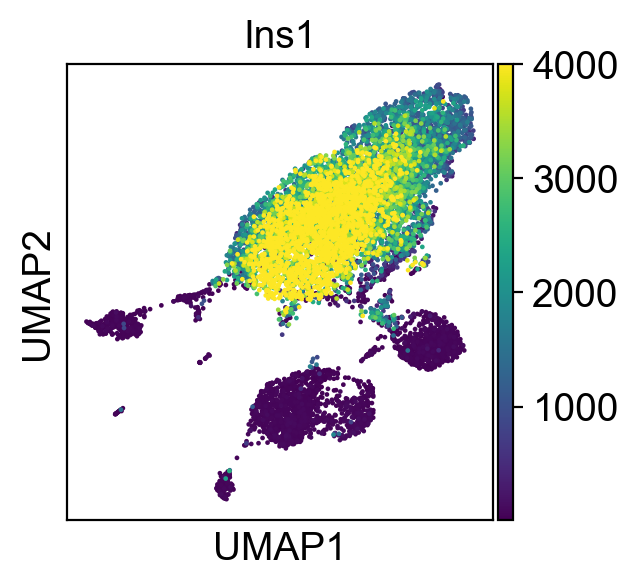

In [15]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(3, 3))
sc.pl.umap(adata, color='Ins1', vmax=4000, save='fig2f_umap_beta_ins1.png')

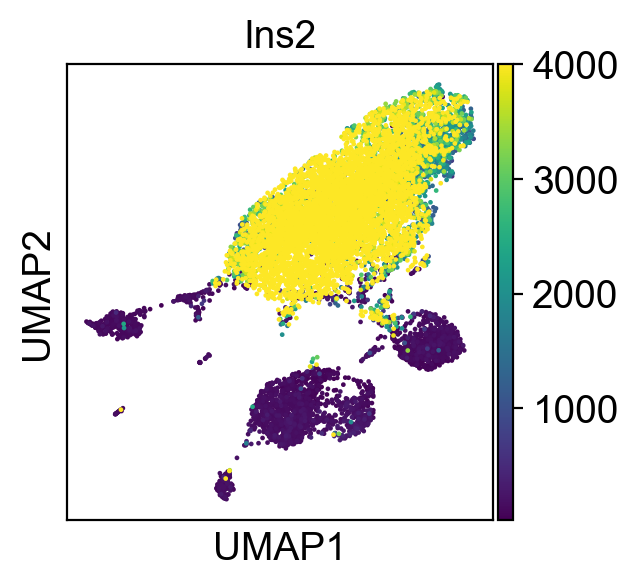

In [16]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(3, 3))
sc.pl.umap(adata, color='Ins2', vmax=4000, save='fig2f_umap_beta_ins2.png')

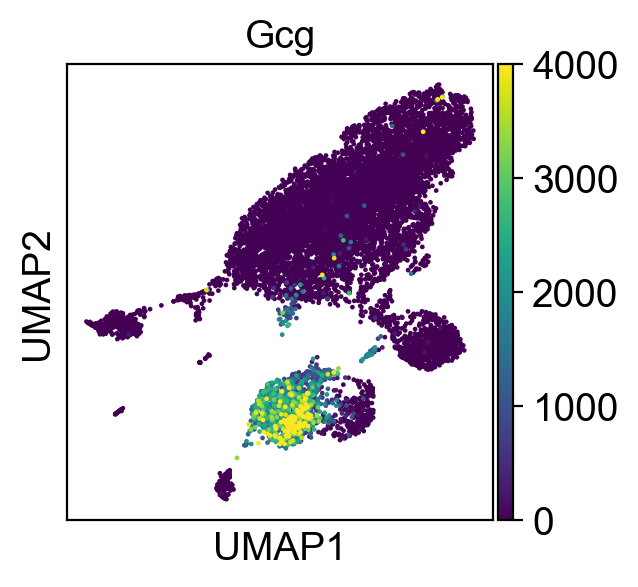

In [17]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(3, 3))
sc.pl.umap(adata, color='Gcg', vmax=4000, save='fig2f_umap_alpha.png')

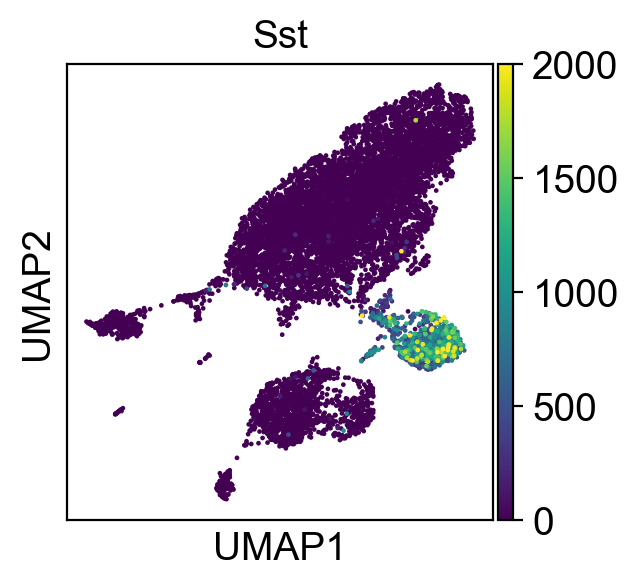

In [19]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(3, 3))
sc.pl.umap(adata, color='Sst', vmax=2000, save='fig2f_umap_delta.png')

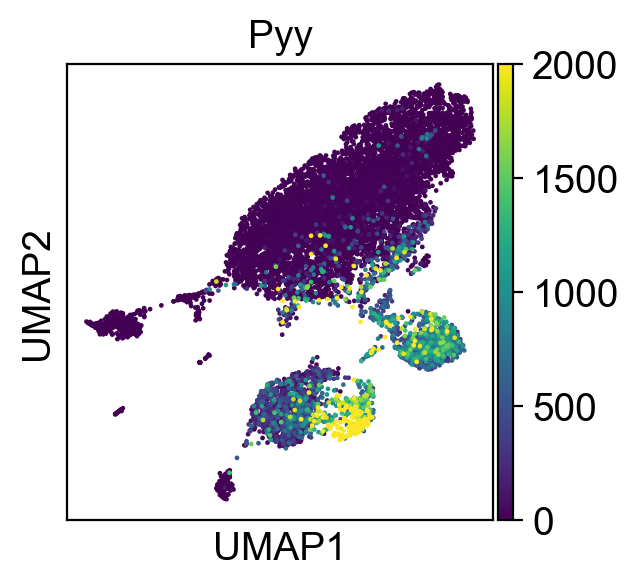

In [20]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(3, 3))
sc.pl.umap(adata, color='Pyy', vmax=2000, save='fig2f_umap_gamma.png')

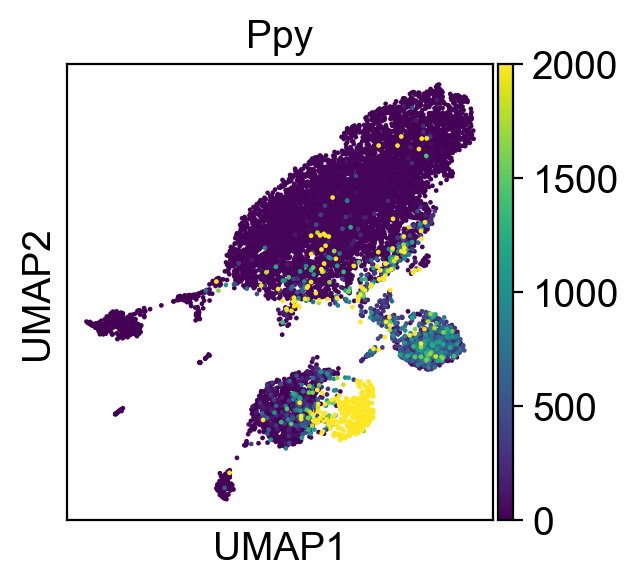

In [21]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(3, 3))
sc.pl.umap(adata, color='Ppy', vmax=2000, save='fig2f_umap_gamma.png')

In [ ]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(6, 6))

candidate_Gpcrs = [
    "",
    "",
    "",
    ""
]

sc.pl.umap(adata, color='Pyy')

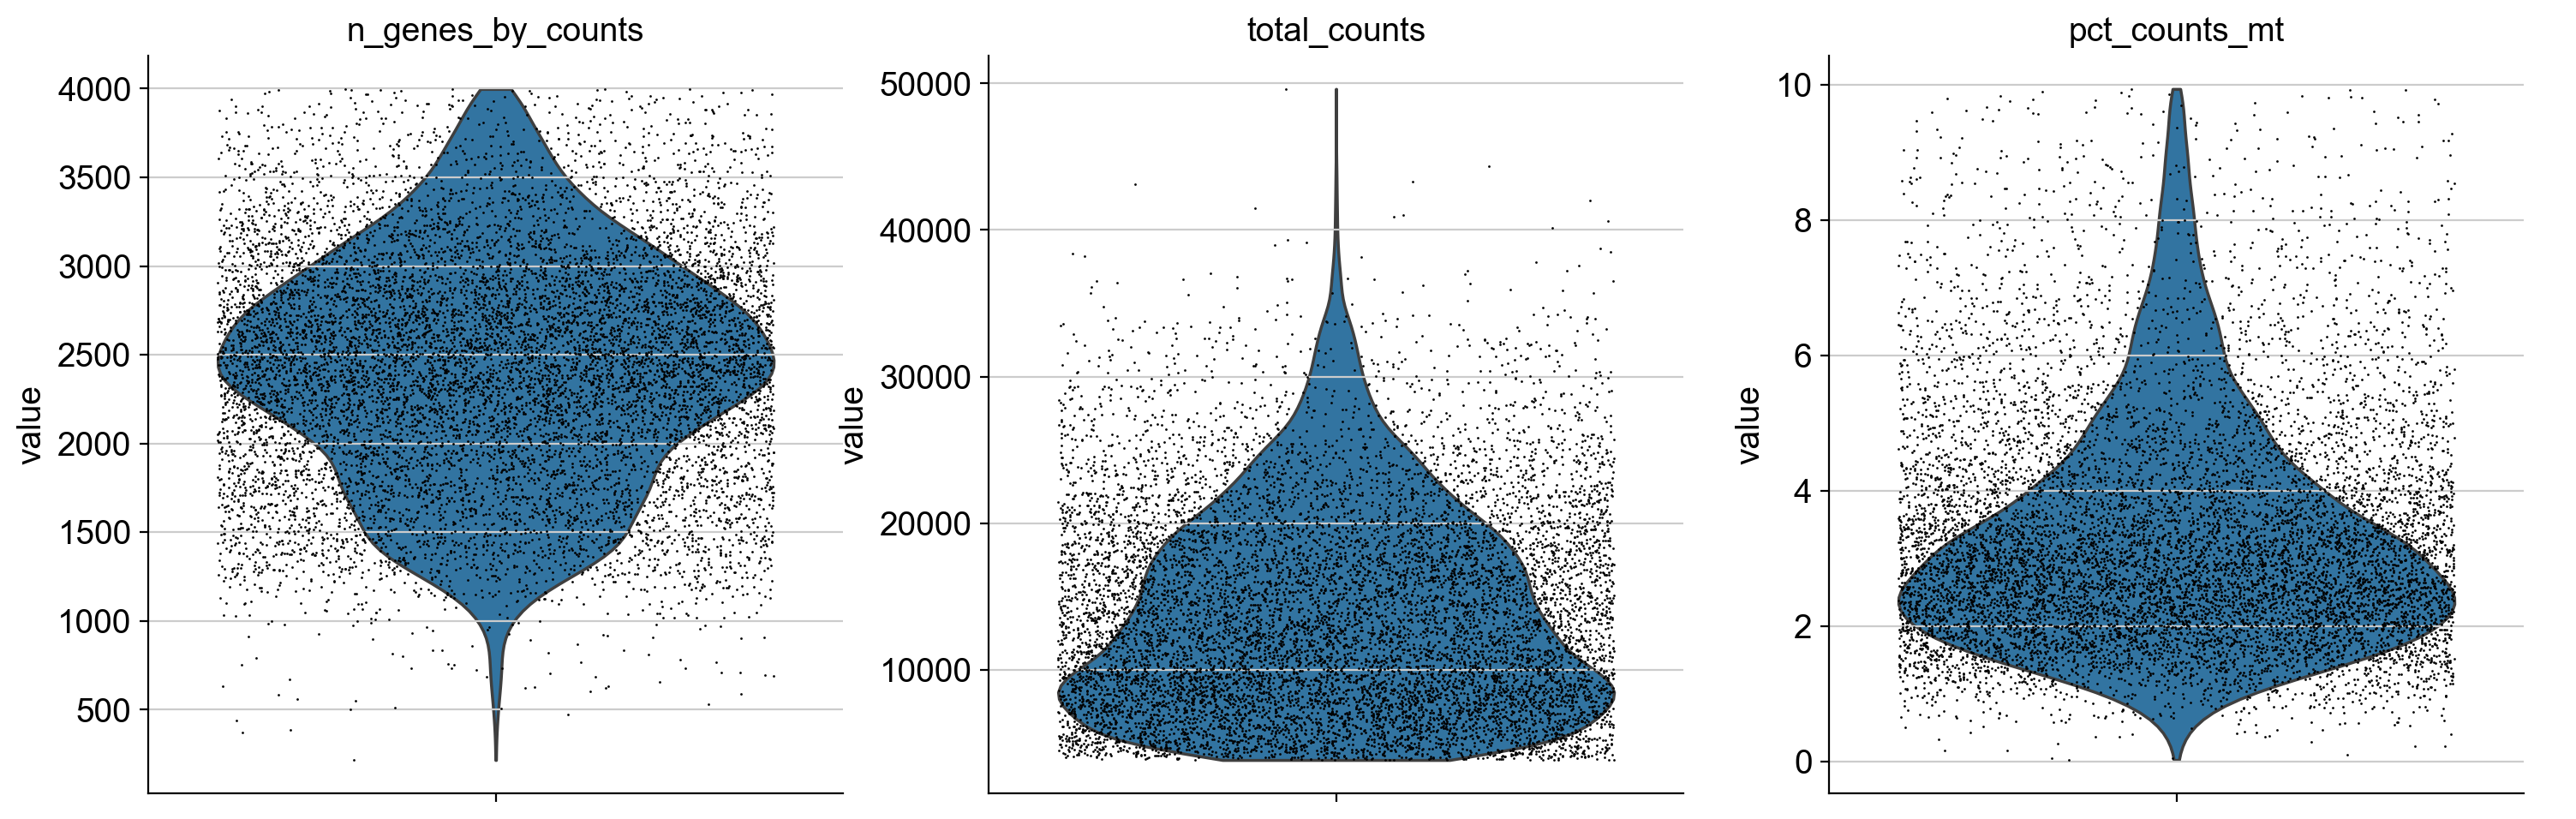

In [87]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter = 0.4,
    multi_panel = True,
    save='figure1b_QC.png'
)

In [33]:
adata_cd = adata[adata.obs['batch'] == 'CD']

In [109]:
adata_cd[adata_cd.obs['leiden_new'] == 'Macrophage']

View of AnnData object with n_obs × n_vars = 59 × 2836
    obs: 'pseudo_group', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_new', 'batch'
    var: 'gene_ids', 'mt', 'highly_variable', 'n_cells-CD', 'n_cells_by_counts-CD', 'mean_counts-CD', 'pct_dropout_by_counts-CD', 'total_counts-CD', 'means-CD', 'dispersions-CD', 'dispersions_norm-CD', 'mean-CD', 'std-CD', 'n_cells-HFD', 'n_cells_by_counts-HFD', 'mean_counts-HFD', 'pct_dropout_by_counts-HFD', 'total_counts-HFD', 'means-HFD', 'dispersions-HFD', 'dispersions_norm-HFD', 'mean-HFD', 'std-HFD'
    uns: 'batch_colors', 'leiden_colors', 'leiden_new_colors', 'dendrogram_leiden_new'
    obsm: 'X_pca', 'X_umap'

In [110]:
adata_hfd = adata[adata.obs['batch'] == 'HFD']

In [119]:
adata_hfd[adata_hfd.obs['leiden_new'] == 'Ductal']

View of AnnData object with n_obs × n_vars = 0 × 2836
    obs: 'pseudo_group', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_new', 'batch'
    var: 'gene_ids', 'mt', 'highly_variable', 'n_cells-CD', 'n_cells_by_counts-CD', 'mean_counts-CD', 'pct_dropout_by_counts-CD', 'total_counts-CD', 'means-CD', 'dispersions-CD', 'dispersions_norm-CD', 'mean-CD', 'std-CD', 'n_cells-HFD', 'n_cells_by_counts-HFD', 'mean_counts-HFD', 'pct_dropout_by_counts-HFD', 'total_counts-HFD', 'means-HFD', 'dispersions-HFD', 'dispersions_norm-HFD', 'mean-HFD', 'std-HFD'
    uns: 'batch_colors', 'leiden_colors', 'leiden_new_colors', 'dendrogram_leiden_new'
    obsm: 'X_pca', 'X_umap'

In [99]:
adata.obs['leiden_new']

AAACCTGAGGCCATAG-1-HFD    β
AAACCTGCAGACACTT-1-HFD    β
AAACCTGCAGCCTATA-1-HFD    β
AAACCTGGTCTCTCTG-1-HFD    β
AAACGGGAGACTACAA-1-HFD    β
                         ..
TTTGTCATCAAAGTAG-1-CD     γ
TTTGTCATCATCGCTC-1-CD     β
TTTGTCATCGTGGTCG-1-CD     β
TTTGTCATCTGCGGCA-1-CD     γ
TTTGTCATCTGGCGAC-1-CD     β
Name: leiden_new, Length: 10440, dtype: category
Categories (8, object): ['α' < 'β' < 'δ' < 'γ' < 'Ductal' < 'MSC' < 'Endothelial' < 'Macrophage']

## Jess Genes

In [13]:
adata.obs

,pseudo_group,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,leiden_new,batch
AAACCTGAGGCCATAG-1-HFD,5,1463,1463,7476.0,187.0,2.501338,β-s3,β,HFD
AAACCTGCAGACACTT-1-HFD,4,2523,2523,17820.0,391.0,2.194164,β-s2,β,HFD
AAACCTGCAGCCTATA-1-HFD,5,1767,1767,7064.0,441.0,6.242922,β-s2,β,HFD
AAACCTGGTCTCTCTG-1-HFD,4,1805,1805,5813.0,293.0,5.040427,β-s2,β,HFD
AAACGGGAGACTACAA-1-HFD,5,1670,1670,4132.0,66.0,1.597289,β-s1,β,HFD
...,...,...,...,...,...,...,...,...,...
TTTGTCATCAAAGTAG-1-CD,3,2075,2075,9095.0,334.0,3.672348,γ,γ,CD
TTTGTCATCATCGCTC-1-CD,3,2081,2081,9581.0,686.0,7.160004,β-s1,β,CD
TTTGTCATCGTGGTCG-1-CD,3,1277,1277,4768.0,213.0,4.467282,β-s3,β,CD
TTTGTCATCTGCGGCA-1-CD,2,2101,2101,11558.0,201.0,1.739055,γ,γ,CD


In [29]:
adata_endo = adata[adata.obs['leiden_new'].isin(["α","β","δ","γ"])]

Unknown type for standard_scale, ignored
saving figure to file figures\matrixplot_jess_heatmap_rgs_obs.png


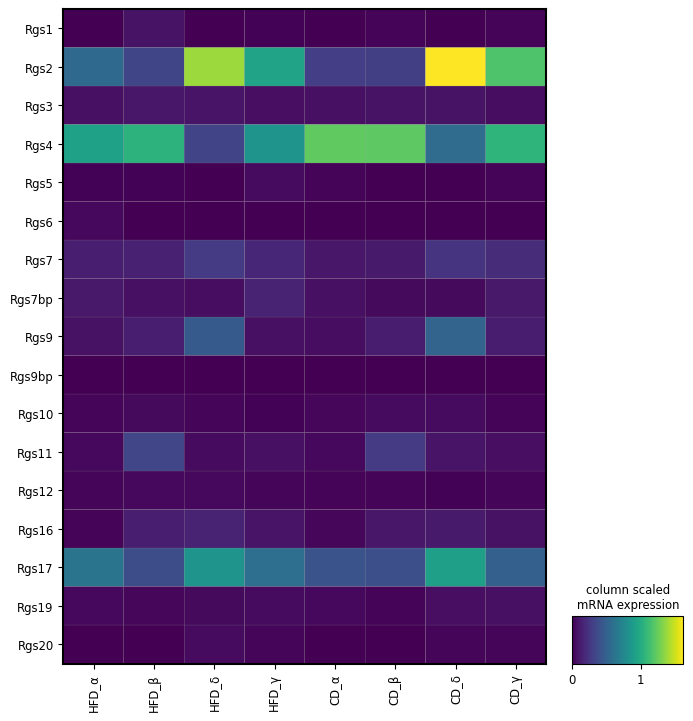

In [30]:
markers = [
    "Rgs1",
    "Rgs2",
    "Rgs3",
    "Rgs4",
    "Rgs5",
    "Rgs6",
    "Rgs7",
    "Rgs7bp",
    "Rgs9",
    "Rgs9bp",
    "Rgs10",
    "Rgs11",
    "Rgs12",
    "Rgs16",
    "Rgs17",
    "Rgs19",
    "Rgs20"
]

sc.pl.matrixplot(adata_endo, markers, ['batch','leiden_new'], dendrogram=False, cmap='viridis',figsize=(8, 8.5),
                standard_scale='obs', colorbar_title='column scaled\nmRNA expression', swap_axes=True, save='jess_heatmap_rgs_obs.png')

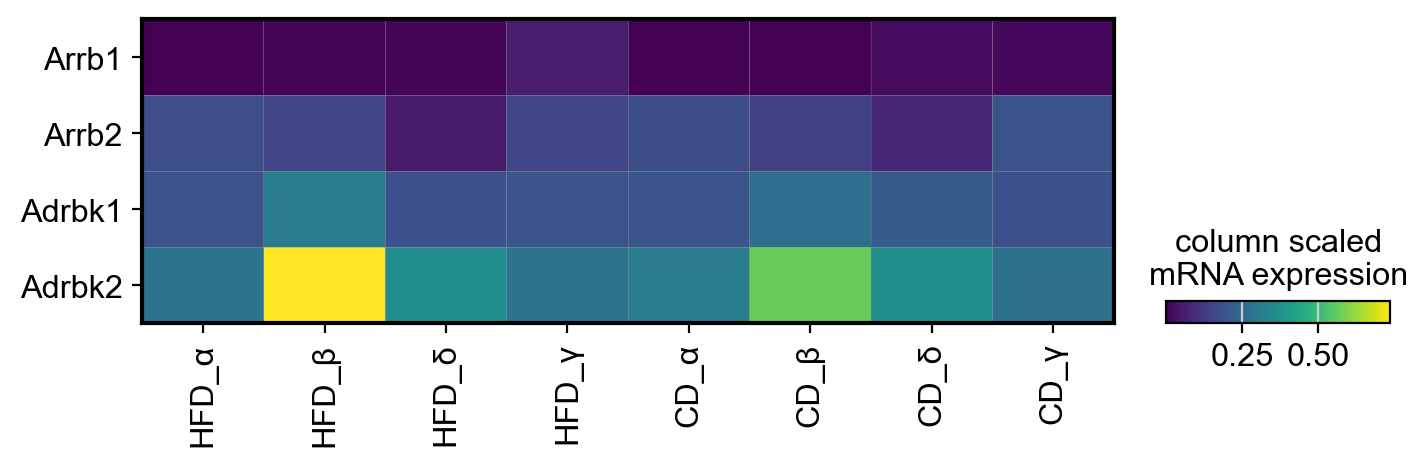

In [43]:
markers = [
    "Arrb1",
    "Arrb2",
    "Adrbk1",
    "Adrbk2"
]

sc.pl.matrixplot(adata_endo, markers, ['batch','leiden_new'], dendrogram=False, cmap='viridis',figsize=(8, 2),
                standard_scale='obs', colorbar_title='column scaled\nmRNA expression', swap_axes=True, save='jess_heatmap_arrb_obs.png')

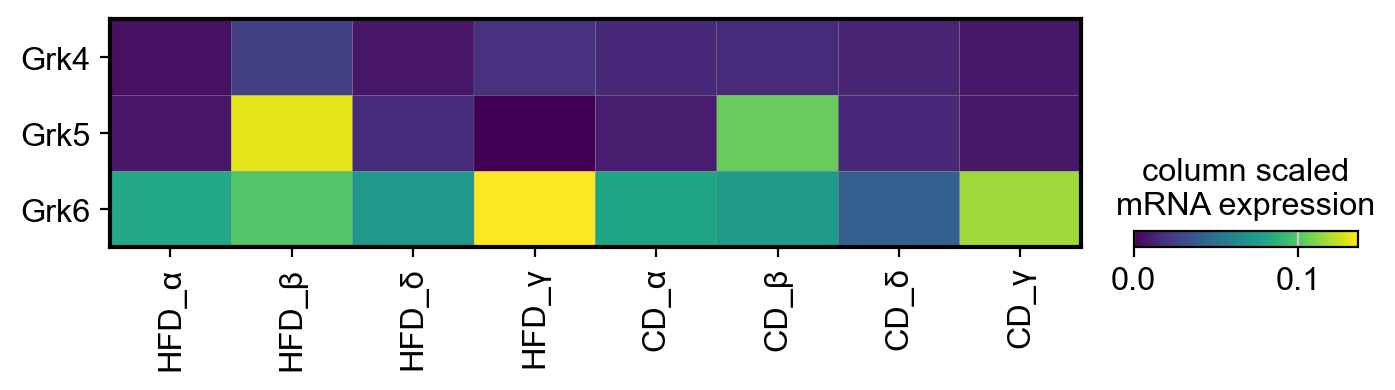

In [45]:
markers = [
    "Grk4",
    "Grk5",
    "Grk6"
]

sc.pl.matrixplot(adata_endo, markers, ['batch','leiden_new'], dendrogram=False, cmap='viridis',figsize=(8, 1.5),
                standard_scale='obs', colorbar_title='column scaled\nmRNA expression', swap_axes=True, save='jess_heatmap_grk_obs.png')

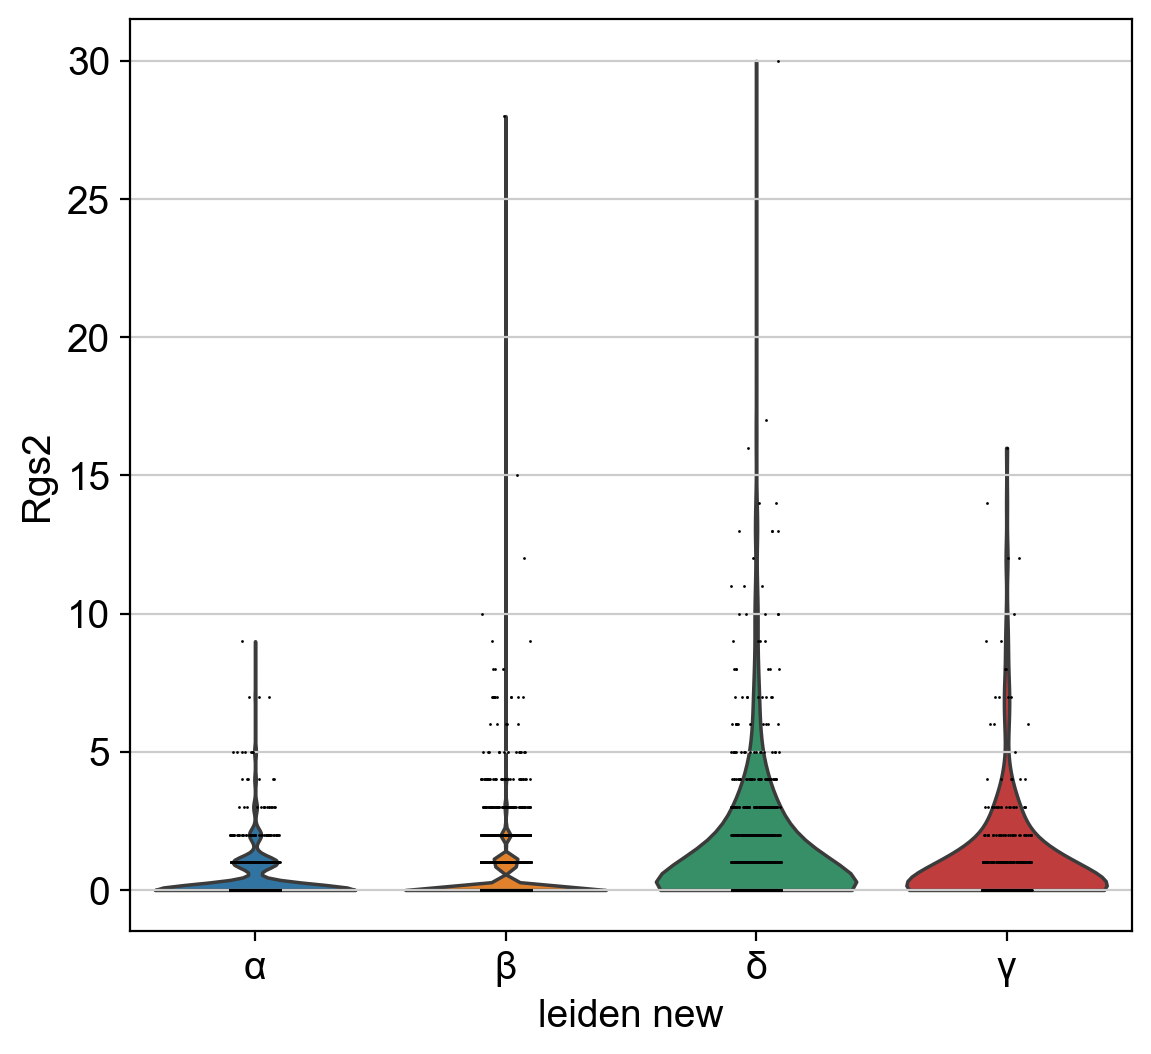

In [46]:
sc.pl.violin(adata_endo, 'Rgs2', groupby='leiden_new', save='violin_rgs2.png')

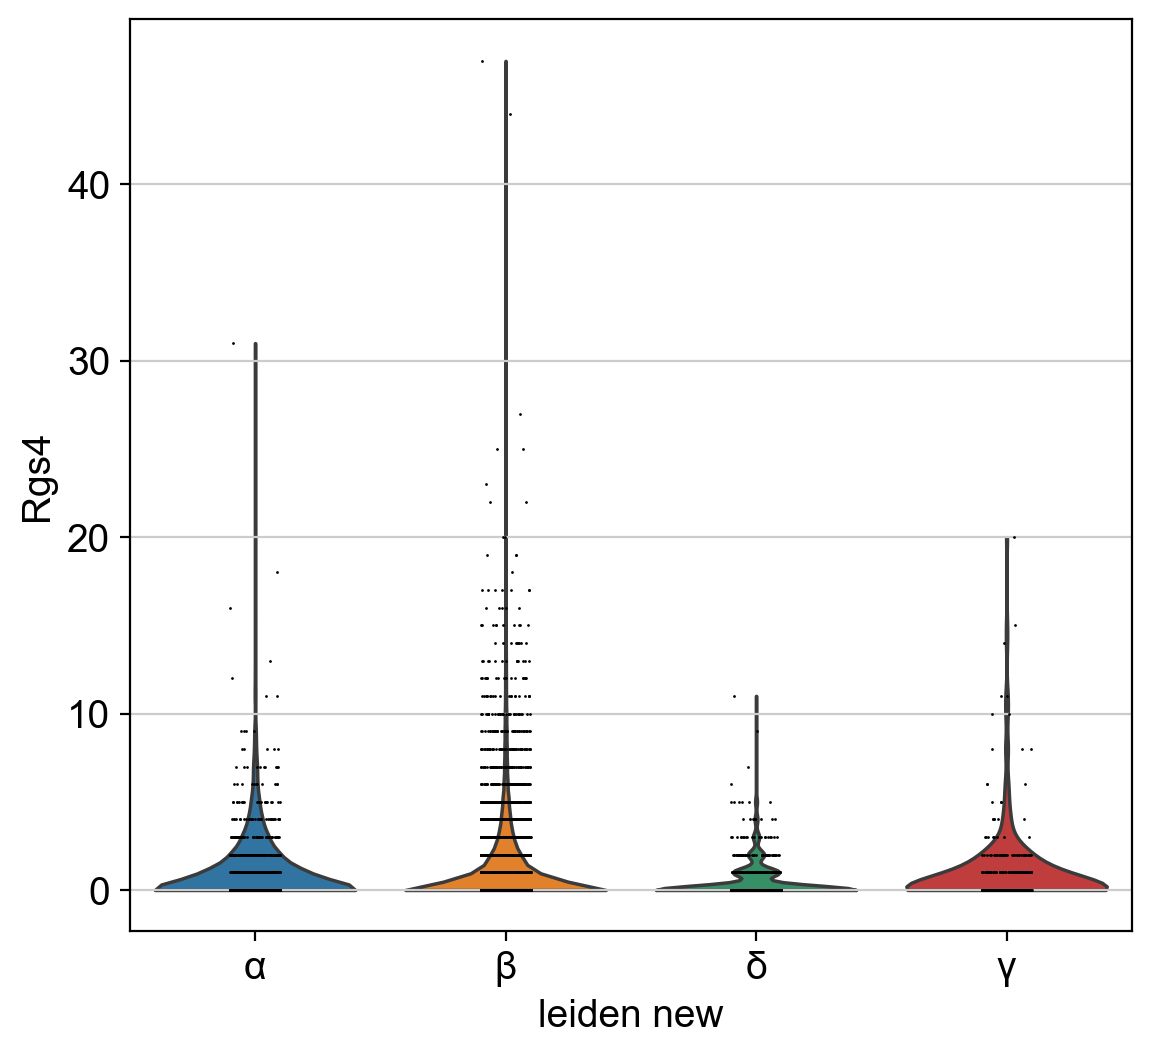

In [47]:
sc.pl.violin(adata_endo, 'Rgs4', groupby='leiden_new', save='violin_rgs4.png')

In [ ]:
sc.pl.violin(adata_endo, 'Rgs4', groupby='leiden_new')

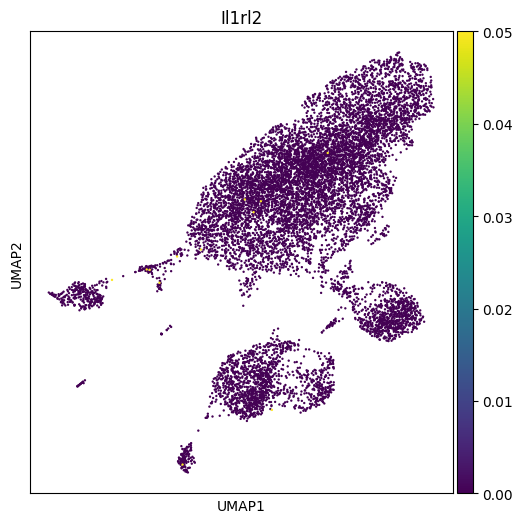

In [13]:
sc.pl.umap(adata, color='Il1rl2', vmax = 0.05)

In [27]:
mpl.rcParams.update({
    "figure.figsize": (10, 10),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.sans-serif": ["DejaVu Sans"],  # 稳定
    # 不设置 pdf.fonttype = 42
})

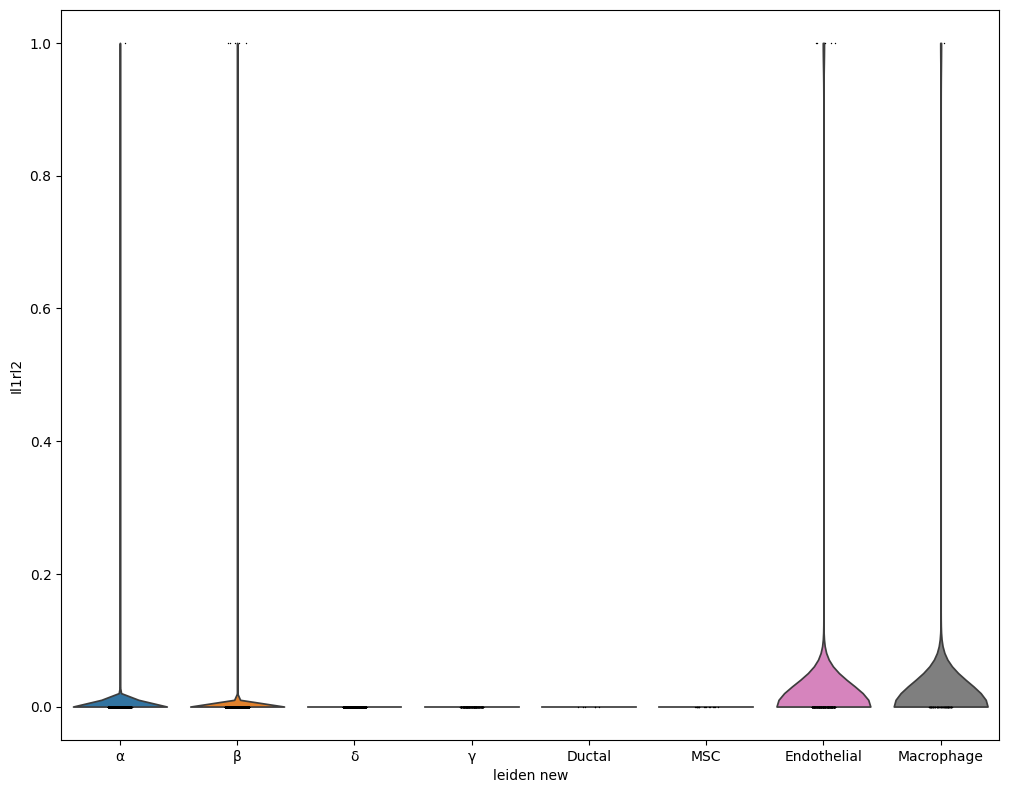

In [28]:
sc.pl.violin(adata, 'Il1rl2', groupby='leiden_new')

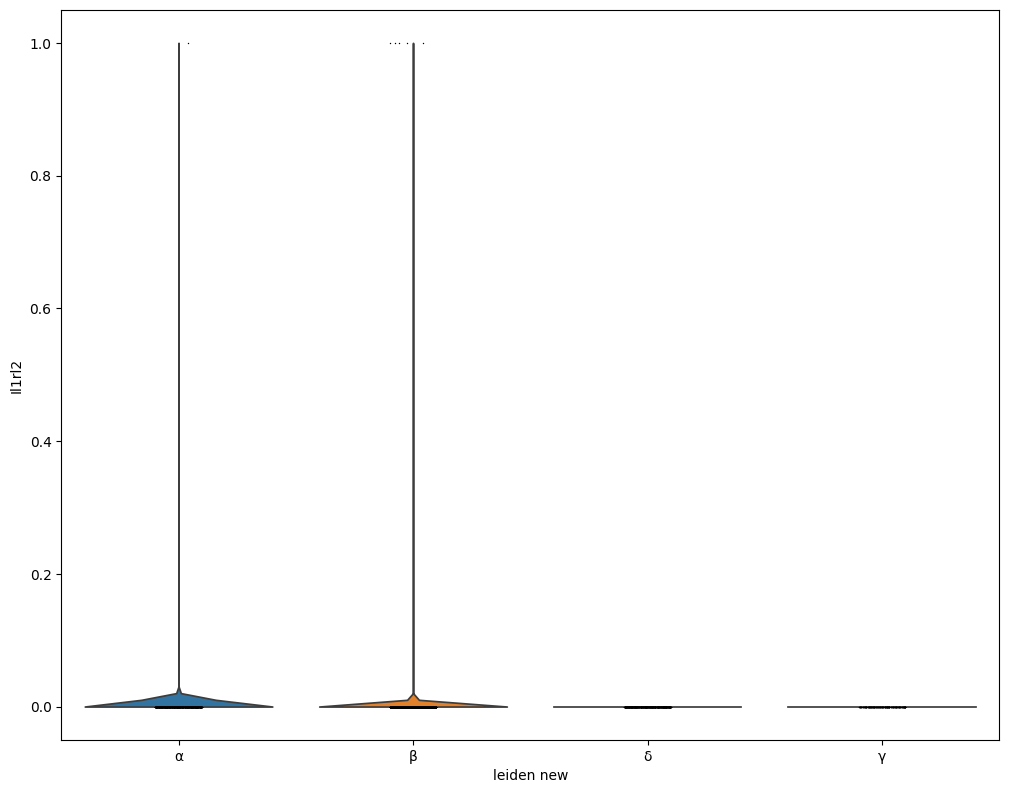

In [31]:
sc.pl.violin(adata_endo, 'Il1rl2', groupby='leiden_new')

Unknown type for standard_scale, ignored


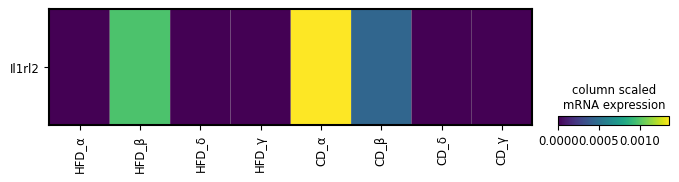

In [32]:
sc.pl.matrixplot(adata_endo, 'Il1rl2', ['batch','leiden_new'], dendrogram=False, cmap='viridis',figsize=(8, 1.5),
                standard_scale='obs', colorbar_title='column scaled\nmRNA expression', swap_axes=True)

Unknown type for standard_scale, ignored


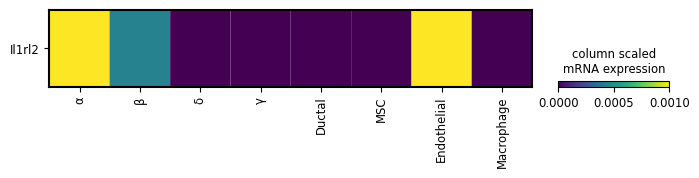

In [37]:
sc.pl.matrixplot(adata_cd, 'Il1rl2', ['leiden_new'], dendrogram=False, cmap='viridis',figsize=(8, 1),
                standard_scale='obs', colorbar_title='column scaled\nmRNA expression', swap_axes=True, vmax=0.001)

In [42]:
sc.pl.violin(adata_cd, 'IL36RN', groupby='leiden_new')

KeyError: "Could not find keys ['IL36RN'] in columns of `adata.obs` or in adata.raw.var_names."